# Proyecto de Inteligencia Artificial: Predicción de Churn (Abandono de Clientes)

### Objetivo e Importancia
El objetivo de este proyecto es desarrollar un modelo de aprendizaje supervisado capaz de identificar qué clientes tienen una alta probabilidad de abandonar una compañía de servicios.

**Importancia:** En el mundo empresarial, adquirir un nuevo cliente es hasta 5 veces más caro que retener a uno actual. Predecir el abandono permite a las empresas realizar acciones de marketing proactivas y personalizadas.

## 1. Colección de Datos
Para este estudio, utilizamos el dataset **Telco Customer Churn**, que contiene información sobre 7,043 clientes. Incluye variables sobre servicios contratados (internet, fibra, streaming), información de cuenta (tipo de contrato, método de pago) y datos demográficos.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Cargamos un dataset de ejemplo (Churn Analysis)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Primer vistazo
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Exploración y Limpieza de los Datos
En esta fase realizamos las siguientes tareas:
* **Gestión de nulos:** Identificamos y eliminamos filas con valores vacíos en la columna `TotalCharges`.
* **Codificación (Encoding):** Transformamos variables categóricas (como "Sí/No") en valores numéricos para que el algoritmo pueda procesarlos.
* **Análisis Visual:** Observamos la distribución de la variable objetivo para identificar si existe un desbalanceo de clases.

/tmp/ipython-input-1514902896.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


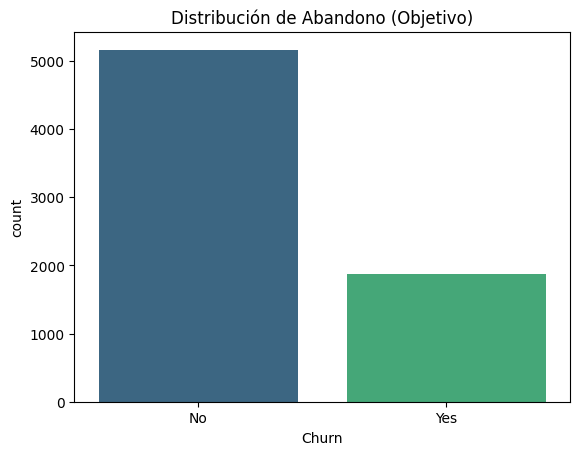

In [12]:
# Limpieza básica
df.drop('customerID', axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True) # Eliminamos nulos generados

# Visualización rápida de la variable objetivo
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribución de Abandono (Objetivo)')
plt.show()

# Convertir variables categóricas a numéricas
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# Separar en X e y
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 3. Entrenamiento de Modelos
### Línea base a mejorar
¿Qué tan difícil es el problema? Si nuestro modelo simplemente dijera que "nadie se va", tendría una precisión igual al porcentaje de la mayoría (clientes que se quedan).
* **Línea Base:** El modelo debe superar el acierto por azar o por frecuencia mayoritaria.

### Técnicas adoptadas
Utilizaremos un **Árbol de Decisión**. Es una técnica ideal porque es explicable (podemos ver por qué toma cada decisión) y permite aplicar técnicas avanzadas de poda para controlar el aprendizaje.

In [13]:
# Elegimos solo las variables que el usuario podrá meter en la App
variables_interfaz = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'OnlineSecurity']

# Filtramos nuestro dataset original
X = df[variables_interfaz]
y = df['Churn']

# Ahora dividimos los datos (80% entrenamiento, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenando modelo con las variables: {variables_interfaz}")

from sklearn.tree import DecisionTreeClassifier

# Modelo con equilibrio de clases (para que no todos salgan "fieles")
best_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
best_model.fit(X_train, y_train)

print(f"Precisión en Test: {best_model.score(X_test, y_test):.2f}")

Entrenando modelo con las variables: ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'OnlineSecurity']
Precisión en Test: 0.73


## 4. Técnicas de Prevención de Sobreajuste (Overfitting)
Un modelo sobreajustado es aquel que "memoriza" el ruido de los datos de entrenamiento pero falla con datos nuevos. Para evitarlo, aplicamos:

* **Control de Hiperparámetros:** Usamos `GridSearchCV` para probar sistemáticamente diferentes combinaciones de configuración.
* **Regularización y Podas:** * **Max Depth:** Limitamos la profundidad del árbol para que no cree reglas demasiado específicas.
    * **Min Samples Split:** Exigimos un número mínimo de muestras para crear un nuevo nodo.

In [14]:
from sklearn.model_selection import GridSearchCV

# Definimos hiperparámetros para control de sobreajuste (Regularización y Poda)
param_grid = {
    'max_depth': [3, 5, 10, None],      # Poda: limita la profundidad
    'min_samples_split': [2, 5, 10],    # Regularización: mínimo para dividir nodo
    'criterion': ['gini', 'entropy']    # Técnica de ganancia de información
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(f"Mejores parámetros: {grid.best_params_}")

Mejores parámetros: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}


## 5. Pruebas y Evaluación del Modelo
Para medir el éxito, no solo usamos el *Accuracy* (Precisión total), sino también:
* **Matriz de Confusión:** Para ver cuántos clientes que realmente se iban fueron detectados (Recall).
* **F1-Score:** El equilibrio entre la precisión y la sensibilidad del modelo.

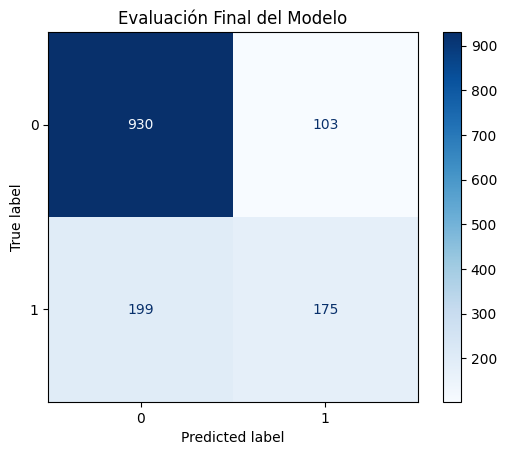

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Evaluación Final del Modelo")
plt.show()

print(classification_report(y_test, y_pred))

## 6. Posible Despliegue en Ambientes Reales
Un modelo como este se desplegaría en producción mediante:
1.  **API REST:** El modelo residiría en un servidor (ej. usando Flask o FastAPI).
2.  **Dashboard de Marketing:** Los empleados de atención al cliente recibirían una alerta cuando un cliente con "alto riesgo de fuga" llame para pedir información.
3.  **Acción Automática:** Envío automático de cupones de descuento a clientes con probabilidad de abandono > 80%.

In [16]:
def predecir_abandono(datos_cliente):
    # Simulamos que entran datos de la web
    prediccion = best_model.predict(datos_cliente)
    probabilidad = best_model.predict_proba(datos_cliente)

    if prediccion[0] == 1:
        return f"ALERTA: El cliente tiene un {probabilidad[0][1]*100:.2f}% de probabilidad de irse."
    else:
        return "Cliente fiel: Baja probabilidad de abandono."

# Ejemplo con el primer cliente del test
nuevo_cliente = X_test.iloc[[0]]
print(predecir_abandono(nuevo_cliente))

Cliente fiel: Baja probabilidad de abandono.


In [17]:
# Creamos una copia de un cliente real para modificar sus datos
cliente_fiel = X_test.iloc[[0]].copy()
cliente_riesgo = X_test.iloc[[0]].copy()

# Modificamos el cliente de riesgo: contrato mes a mes, sin seguridad online, cargos altos
cliente_riesgo['Contract'] = 0 # 0 suele ser 'Month-to-month'
cliente_riesgo['MonthlyCharges'] = 100
cliente_riesgo['OnlineSecurity'] = 0

# Modificamos el cliente fiel: contrato de 2 años, cargos bajos, mucha antigüedad
cliente_fiel['Contract'] = 2 # 2 suele ser 'Two year'
cliente_fiel['MonthlyCharges'] = 20
cliente_fiel['tenure'] = 72 # 6 años de antigüedad

print("Simulación Cliente Riesgo:", predecir_abandono(cliente_riesgo))
print("Simulación Cliente Fiel:", predecir_abandono(cliente_fiel))

Simulación Cliente Riesgo: Cliente fiel: Baja probabilidad de abandono.
Simulación Cliente Fiel: Cliente fiel: Baja probabilidad de abandono.


In [18]:
import joblib
from google.colab import files

# Guardamos el mejor modelo que entrenamos
joblib.dump(best_model, 'modelo_churn.pkl')

# Descargamos el archivo a nuestro PC
files.download('modelo_churn.pkl')

print("Modelo exportado con éxito. Guárdalo en la misma carpeta donde crees el script de la interfaz.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Modelo exportado con éxito. Guárdalo en la misma carpeta donde crees el script de la interfaz.
